In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set random seed for reproducibility
np.random.seed(42)

# Generate ~4000 records
n_records = 4000

emp_ids = [f"EMP_{i:04d}" for i in range(1, n_records + 1)]
departments = np.random.choice(['Sales', 'IT', 'HR', 'Finance', 'Marketing'], size=n_records, p=[0.25, 0.30, 0.15, 0.15, 0.15])
ages = np.random.randint(22, 60, size=n_records)
salaries = np.random.exponential(scale=20000, size=n_records) + 30000  # Skewed salary distribution
projects_completed = np.random.poisson(lam=5, size=n_records)
working_hours = np.random.normal(loc=40, scale=5, size=n_records).clip(20, 60)
performance_score = np.random.normal(loc=70, scale=15, size=n_records).clip(0, 100)

# Higher performance score increases chance of promotion
promo_prob = 1 / (1 + np.exp(-(performance_score - 75) / 10))
promotion_status = np.where(np.random.rand(n_records) < promo_prob, 'Yes', 'No')

# Create DataFrame & export to CSV
df = pd.DataFrame({
    'Employee_ID': emp_ids,
    'Department': departments,
    'Age': ages,
    'Salary': np.round(salaries, 2),
    'Projects_Completed': projects_completed,
    'Working_Hours': np.round(working_hours, 1),
    'Performance_Score': np.round(performance_score, 1),
    'Promotion_Status': promotion_status
})

df.to_csv('employee_performance.csv', index=False)
print("Dataset 'employee_performance.csv' successfully created with 4000 records!\n")
print(df.head())

Dataset 'employee_performance.csv' successfully created with 4000 records!

  Employee_ID Department  Age    Salary  Projects_Completed  Working_Hours  \
0    EMP_0001         IT   42  47042.47                   2           41.7   
1    EMP_0002  Marketing   58  34847.64                   5           43.2   
2    EMP_0003    Finance   48  69555.75                   6           39.8   
3    EMP_0004         HR   50  87010.30                   6           36.0   
4    EMP_0005      Sales   41  44616.69                   4           43.8   

   Performance_Score Promotion_Status  
0               82.0              Yes  
1               62.9               No  
2              100.0              Yes  
3               73.3               No  
4               87.7              Yes  


In [2]:
# 1. Mean, Median, and Mode of Salary
salary_mean = df['Salary'].mean()
salary_median = df['Salary'].median()
salary_mode = df['Salary'].mode()[0]

print("--- Step 1: Central Tendency & Dispersion ---")
print(f"Salary Mean: ${salary_mean:.2f}")
print(f"Salary Median: ${salary_median:.2f}")
print(f"Salary Mode: ${salary_mode:.2f}")

# 2. Variance and Standard Deviation of Projects_Completed
projects_var = df['Projects_Completed'].var()
projects_std = df['Projects_Completed'].std()

print(f"\nProjects Completed Variance: {projects_var:.4f}")
print(f"Projects Completed Standard Deviation: {projects_std:.4f}")

--- Step 1: Central Tendency & Dispersion ---
Salary Mean: $49312.40
Salary Median: $43611.65
Salary Mode: $31501.98

Projects Completed Variance: 5.0199
Projects Completed Standard Deviation: 2.2405


In [3]:
print("--- Step 2: Probability & Events ---")

# 1. Probability of employees getting promoted
total_employees = len(df)
promoted_count = (df['Promotion_Status'] == 'Yes').sum()
p_promotion = promoted_count / total_employees
print(f"P(Promotion = Yes): {p_promotion:.4f} ({p_promotion*100:.2f}%)")

# 2. Contingency Table between Promotion_Status and Department
contingency_table = pd.crosstab(df['Department'], df['Promotion_Status'], margins=True)
print("\nContingency Table (Department vs Promotion Status):")
print(contingency_table)

# 3. Conditional Probability: P(Promotion | Performance_Score > 80)
high_performers = df[df['Performance_Score'] > 80]
promoted_high_performers = high_performers[high_performers['Promotion_Status'] == 'Yes']

p_cond_promotion = len(promoted_high_performers) / len(high_performers)
print(f"\nP(Promotion | Performance_Score > 80): {p_cond_promotion:.4f} ({p_cond_promotion*100:.2f}%)")

--- Step 2: Probability & Events ---
P(Promotion = Yes): 0.4130 (41.30%)

Contingency Table (Department vs Promotion Status):
Promotion_Status    No   Yes   All
Department                        
Finance            350   248   598
HR                 352   263   615
IT                 707   465  1172
Marketing          345   244   589
Sales              594   432  1026
All               2348  1652  4000

P(Promotion | Performance_Score > 80): 0.7751 (77.51%)


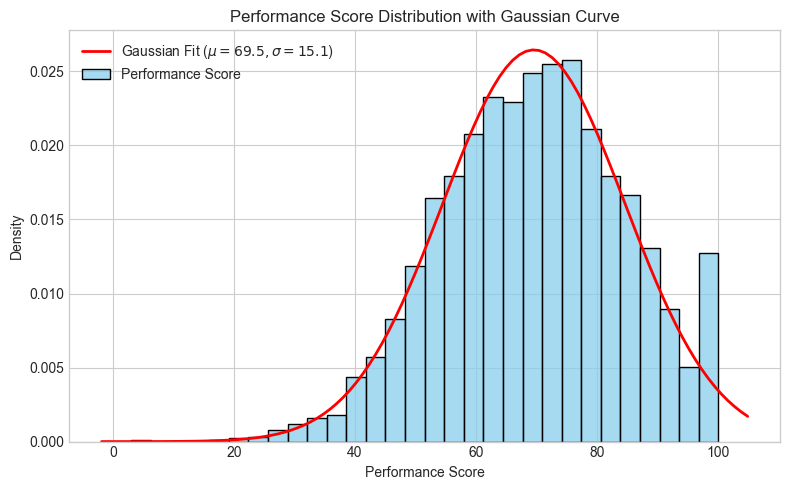

--- Step 3 Metrics ---
Salary Skewness: 1.9100
Salary Kurtosis: 5.2756


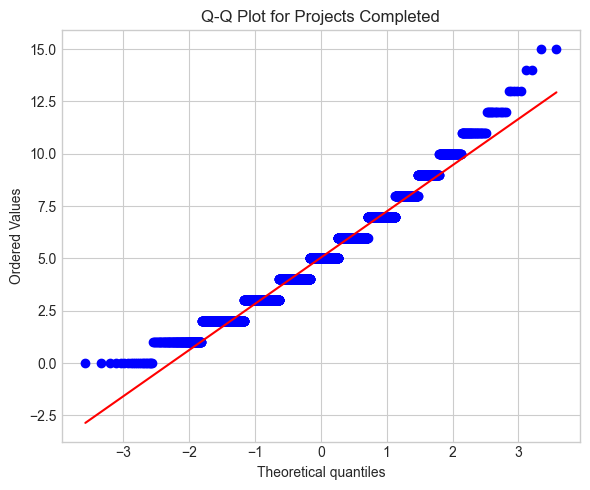

In [6]:
# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Histogram of Performance_Score with Gaussian Curve
plt.figure(figsize=(8, 5))
sns.histplot(df['Performance_Score'], kde=False, stat="density", color="skyblue", bins=30, label="Performance Score")

# Fit Gaussian (Normal) curve
mu, std = stats.norm.fit(df['Performance_Score'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label=rf'Gaussian Fit ($\mu={mu:.1f}, \sigma={std:.1f}$)')

plt.title('Performance Score Distribution with Gaussian Curve')
plt.xlabel('Performance Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Check Skewness and Kurtosis for Salary
salary_skew = df['Salary'].skew()
salary_kurt = df['Salary'].kurtosis()

print("--- Step 3 Metrics ---")
print(f"Salary Skewness: {salary_skew:.4f}")
print(f"Salary Kurtosis: {salary_kurt:.4f}")

# 3. Q-Q Plot of Projects_Completed
plt.figure(figsize=(6, 5))
stats.probplot(df['Projects_Completed'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Projects Completed')
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
print("--- Step 4: Linear Algebra Application ---")

# 1. Extract first 5 employees' [Projects_Completed, Working_Hours] as vectors
vectors = df[['Projects_Completed', 'Working_Hours']].head(5).to_numpy()
print("First 5 Employee Vectors [Projects_Completed, Working_Hours]:")
for i, vec in enumerate(vectors):
    print(f"Employee {i+1} Vector: {vec}")

# 2. Dot product between Employee 1 and Employee 2 vectors
v1 = vectors[0]
v2 = vectors[1]
dot_product = np.dot(v1, v2)
print(f"\nDot Product (Employee 1 . Employee 2): {dot_product:.2f}")

# 3. Norm 1 & Norm 2 of Employee 1's vector
norm_1 = np.linalg.norm(v1, ord=1)
norm_2 = np.linalg.norm(v1, ord=2)
print(f"Employee 1 Vector Norm 1 (Manhattan Distance): {norm_1:.2f}")
print(f"Employee 1 Vector Norm 2 (Euclidean Distance): {norm_2:.2f}")

# 4. Compute the angle between Employee 1 and Employee 2 vectors
cos_theta = dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2))
angle_rad = np.arccos(np.clip(cos_theta, -1.0, 1.0))
angle_deg = np.degrees(angle_rad)

print(f"Angle between Employee 1 and Employee 2 vectors: {angle_rad:.4f} radians ({angle_deg:.2f} degrees)")

--- Step 4: Linear Algebra Application ---
First 5 Employee Vectors [Projects_Completed, Working_Hours]:
Employee 1 Vector: [ 2.  41.7]
Employee 2 Vector: [ 5.  43.2]
Employee 3 Vector: [ 6.  39.8]
Employee 4 Vector: [ 6. 36.]
Employee 5 Vector: [ 4.  43.8]

Dot Product (Employee 1 . Employee 2): 1811.44
Employee 1 Vector Norm 1 (Manhattan Distance): 43.70
Employee 1 Vector Norm 2 (Euclidean Distance): 41.75
Angle between Employee 1 and Employee 2 vectors: 0.0673 radians (3.86 degrees)
